In [81]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [83]:
path = "results/{0}_fig7_rho_sub_critical_test_2.p"
#N_range = [int(n) for n in np.geomspace(1e5, 3e6, 10)]
N_range = [ 100000,  145923,  212936, 310723]
num_ensambles = 1700
M = np.empty((len(N_range), num_ensambles))

In [84]:
for n in range(num_ensambles):
    with open(path.format(n), "rb") as f:
        mags = pickle.load(f)
        for N in range(len(N_range)):
            m = mags[N]
            M[N,n] = m

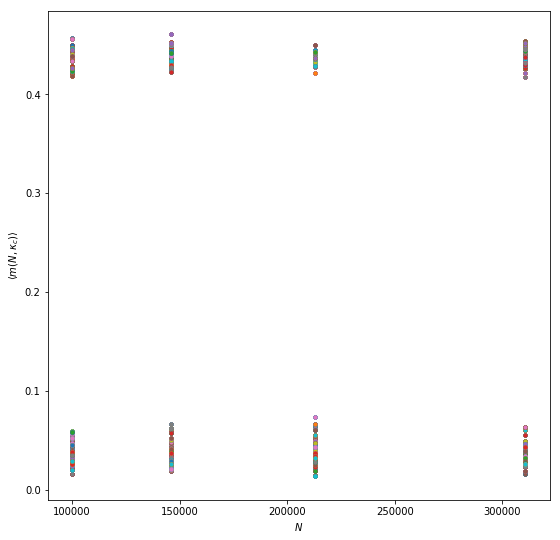

In [32]:
plt.figure(figsize=(9,9))
for n in range(num_ensambles):
    plt.scatter(N_range, M[:, n], s=10)
plt.xlabel(r'$N$')
plt.ylabel(r'$\langle m(N, \kappa_c)\rangle$')
plt.show()

In [85]:
pairs = []

for N in range(len(N_range)):
    ms = M[N]
    md = ms[ms <=0.25]
    if md.size >= ms.size//4:
        pairs.append([N_range[N], -np.mean(md), np.std(md)])
        
pairs = np.array(pairs)

In [76]:
pairs = []

for N in range(len(N_range)):
    ms = M[N]
    md = ms[ms <=0.25]
    if md.size >= 0:#ms.size//4:
        pairs.append([N_range[N], N_range[N]*(np.mean(md**2)-np.mean(md)**2)])
        
pairs = np.array(pairs)

plt.loglog(*pairs[:,:2].T, 'ko')
plt.show()

[0.041167   0.041167   0.041167   0.041167   0.041167   0.041167
 0.041167   0.041167   0.041167   0.041167   0.041167   0.041167
 0.041167   0.041167   0.041167   0.041167   0.041167   0.041167
 0.041167   0.041167   0.041167   0.041167   0.041167   0.041167
 0.041167   0.041167   0.041167   0.041167   0.041167   0.041167
 0.041167   0.041167   0.041167   0.041167   0.041167   0.041167
 0.041167   0.041167   0.041167   0.041167   0.041167   0.041167
 0.041167   0.041167   0.041167   0.041167   0.041167   0.041167
 0.041167   0.041167   0.041167   0.041167   0.041167   0.041167
 0.041167   0.041167   0.041167   0.041167   0.041167   0.041167
 0.041167   0.041167   0.041167   0.041167   0.43847447]
[0.041167   0.041167   0.041167   0.041167   0.041167   0.041167
 0.041167   0.041167   0.041167   0.041167   0.041167   0.041167
 0.041167   0.041167   0.041167   0.041167   0.041167   0.041167
 0.041167   0.041167   0.041167   0.041167   0.041167   0.041167
 0.041167   0.041167   0.041167  

IndexError: too many indices for array

In [86]:
z = np.polyfit(np.log(pairs[:, 0]), np.log(pairs[:, 1]), 1)
print(z)
p = np.poly1d(z)

/home/vladimir/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:1: RuntimeWarning: invalid value encountered in log
  """Entry point for launching an IPython kernel.


LinAlgError: SVD did not converge in Linear Least Squares

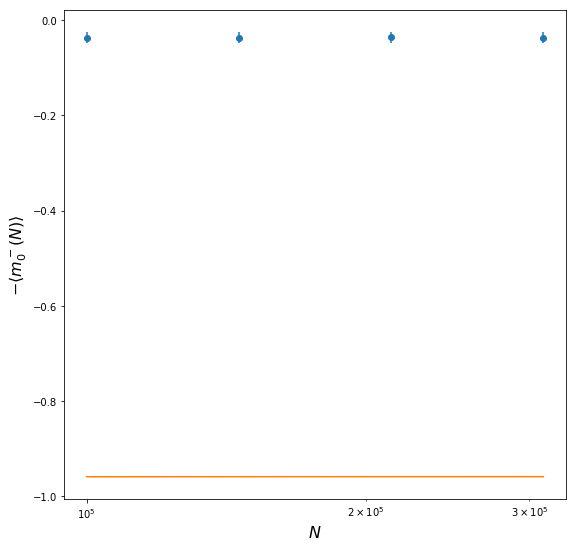

In [87]:
plt.figure(figsize=(9,9))
plt.errorbar(*pairs[:, :2].T, yerr=pairs[:, 2], fmt='o')
plt.plot(pairs[:, 0], p(np.log(pairs[:, 0])))
plt.ylabel(r'$-\langle m_0^-(N)\rangle$', fontsize=16)
plt.xlabel(r'$N$', fontsize=16)
plt.xscale('log')
#plt.yscale('log')
plt.show()

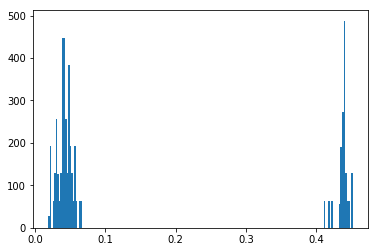

In [68]:
plt.hist(M[0,:], bins=200)
plt.show()

In [82]:
%timeit np.random.seed(1)

1.39 µs ± 2.68 ns per loop (mean ± std. dev. of 7 runs, 1000000 loops each)
